# Online Appendix: Microservice Decomposition Results

This notebook presents the full decomposition results summarised in the main paper.
For each system it shows:
1. **NMI ranking table** — all decompositions ranked by NMI (descending).
2. **Top vs bottom comparison** — side-by-side service groupings for the highest- and lowest-ranked decompositions.
3. **BC mixing** — stacked-bar charts showing how top- vs bottom-ranked decompositions mix classes from different Bounded Contexts within each microservice.
4. **Service grouping detail** — every class assigned to each service, for any decomposition you select.
5. **Pen_data ranking & pairs** — decompositions ranked by data-access penalty, distribution chart, and penalized service-pair detail for best vs worst.
6. **Cross-system NMI summary** — compact comparison table across all systems.

---
### How to use
- Set `RESULTS_CSV` and `DECOMPOSITIONS_PICKLE` to your file paths.
- Set `SYSTEM_COL` to the column that identifies the system (or `None` if you have one CSV per system).
- Run **Kernel → Restart & Run All**.

In [1]:
from mvaa.tests.RQ1.bc_penalty_analysis import build_class_to_bc
from mvaa.utils.graph import read_graphml
import pickle
from mvaa.alignment.alignment import MultiViewAlignments
DEFAULT_SYSTEM_NAME  = "daytrader"
RESULTS_CSV = f"../results/RQ1/metrics_{DEFAULT_SYSTEM_NAME}.csv"
DECOMPOSITIONS_PICKLE = f"../monoliths/{DEFAULT_SYSTEM_NAME}/decompositions_{DEFAULT_SYSTEM_NAME}.pkl"


# How many top/bottom decompositions to show in the comparison section
N_TOP_BOTTOM = 3
G_design = read_graphml(
    f"../monoliths/{DEFAULT_SYSTEM_NAME}/vista_disenio_{DEFAULT_SYSTEM_NAME}.graphml"
)
with open(f"../monoliths/{DEFAULT_SYSTEM_NAME}/alignment_results.pkl", "rb") as f:
    alignment_results = pickle.load(f)

BC_MAPPING    = build_class_to_bc(G_design, alignment_results.P_I_D)

In [2]:
import pickle
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 60)

results = pd.read_csv(RESULTS_CSV)

results['_system'] = DEFAULT_SYSTEM_NAME
SYSTEM_COL = '_system'

systems = sorted(results[SYSTEM_COL].unique())
print(f"Loaded {len(results):,} decompositions across {len(systems)} system(s): {systems}")

with open(DECOMPOSITIONS_PICKLE, 'rb') as f:
    decompositions = pickle.load(f)

print(f"Loaded {len(decompositions):,} decomposition entries from pickle.")

Loaded 235 decompositions across 1 system(s): ['daytrader']
Loaded 235 decomposition entries from pickle.


In [3]:
def short_name(fqn: str) -> str:
    name = fqn.replace('class:', '')
    return name.split('.')[-1]

def membership_to_df(run_id: str) -> pd.DataFrame:
    entry = decompositions.get(run_id)
    if entry is None:
        return pd.DataFrame(columns=['class', 'short_class', 'service'])
    rows = [
        {'class': cls, 'short_class': short_name(cls), 'service': svc}
        for cls, svc in entry['membership'].items()
    ]
    return pd.DataFrame(rows).sort_values(['service', 'short_class']).reset_index(drop=True)

PALETTE = plt.cm.tab20.colors

---
## 1  NMI Ranking Tables
All decompositions sorted by NMI (descending). Key metrics are shown alongside each decomposition ID.

In [4]:
DISPLAY_COLS = ['ID', 'NMI', 'K', 'SERVICES', 'RESOLUTION', 'score_swm']
available_cols = [c for c in DISPLAY_COLS if c in results.columns]

for system in systems:
    df = (
        results[results[SYSTEM_COL] == system][available_cols]
        .sort_values('NMI', ascending=False)
        .reset_index(drop=True)
    )
    df.index += 1  # 1-based rank
    df.index.name = 'Rank'

    display(Markdown(f"### System: `{system}` — {len(df)} decompositions"))

    styled = (
        df.style
        .format({'NMI': '{:.4f}', 'score_swm': '{:.4f}'}, na_rep='—')
        .background_gradient(subset=['NMI'], cmap='YlGn')
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
    )
    display(styled)

### System: `daytrader` — 235 decompositions

,ID,NMI,K,SERVICES,RESOLUTION,score_swm
Rank,,,,,,
1,04_03_18_02_02_826045,0.4791,18,9,0.300000,0.4630
2,04_03_17_49_08_364749,0.4607,8,9,0.300000,0.4348
3,04_03_17_52_00_575877,0.4402,9,9,0.300000,0.3891
4,04_03_18_00_12_186653,0.4372,15,7,0.800000,0.3960
5,04_03_17_54_20_139418,0.4351,10,11,0.300000,0.4253
6,04_03_18_00_12_213741,0.4252,15,7,0.900000,0.3912
7,04_03_18_00_12_203346,0.4252,15,7,0.900000,0.3912
8,04_03_18_00_12_116297,0.4199,15,9,0.300000,0.3208
9,04_03_17_34_49_149601,0.4145,3,9,0.400000,0.3960


---
## 2  Top vs Bottom Comparison
Side-by-side service groupings for the highest- and lowest-ranked decompositions.

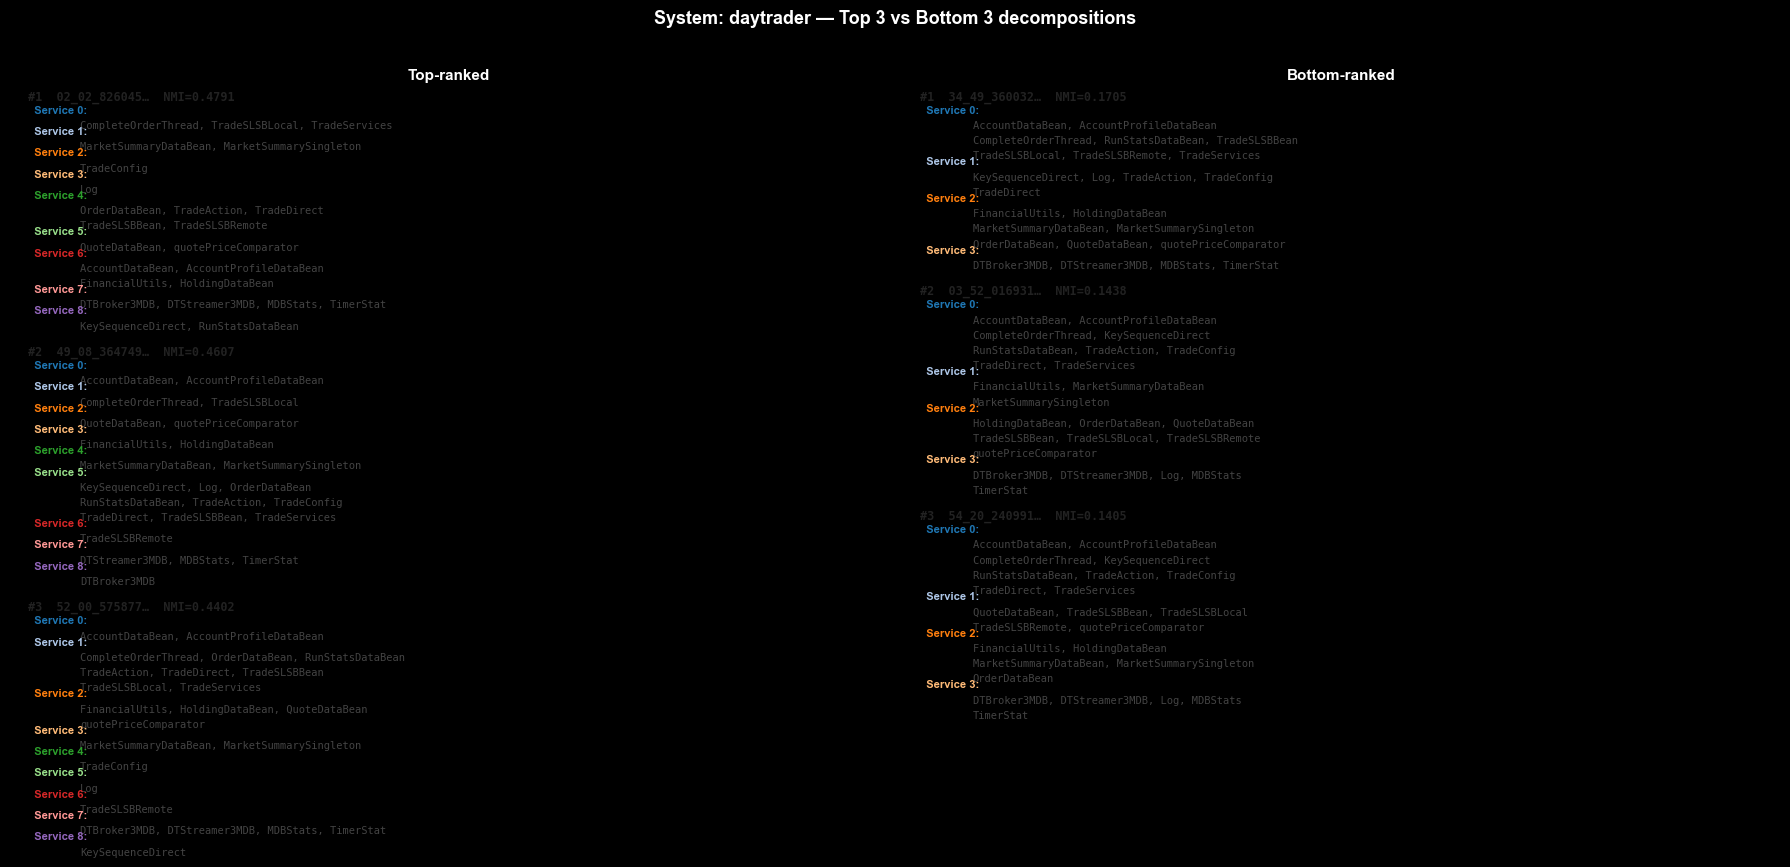

In [5]:
def render_side_by_side(system: str, top_ids: list, bot_ids: list):

    def grouping_text(run_id):
        df = membership_to_df(run_id)
        if df.empty:
            return {}, []
        groups = {svc: list(sub['short_class']) for svc, sub in df.groupby('service')}
        nmi = results.loc[results['ID'] == run_id, 'NMI'].values
        nmi_str = f"NMI={nmi[0]:.4f}" if len(nmi) else ""
        return groups, nmi_str

    fig, axes = plt.subplots(1, 2, figsize=(18, max(8, N_TOP_BOTTOM * 3.5)))
    fig.suptitle(f"System: {system} — Top {N_TOP_BOTTOM} vs Bottom {N_TOP_BOTTOM} decompositions",
                 fontsize=13, fontweight='bold', y=1.01)

    for ax, run_ids, label in zip(axes, [top_ids, bot_ids], ['Top-ranked', 'Bottom-ranked']):
        ax.axis('off')
        ax.set_title(label, fontsize=11, fontweight='bold', pad=8)

        y = 1.0
        line_h = 0.032
        for rank_i, run_id in enumerate(run_ids, 1):
            groups, nmi_str = grouping_text(run_id)
            if not groups:
                continue
            header = f"#{rank_i}  {run_id[-12:]}…  {nmi_str}"
            ax.text(0.02, y, header, transform=ax.transAxes,
                    fontsize=8.5, fontweight='bold', color='#222',
                    va='top', fontfamily='monospace')
            y -= line_h
            for svc_idx, (svc, classes) in enumerate(sorted(groups.items())):
                color = PALETTE[svc_idx % len(PALETTE)]
                svc_label = f"  Service {svc}:"
                ax.text(0.02, y, svc_label, transform=ax.transAxes,
                        fontsize=8, color=color, fontweight='bold', va='top')
                class_str = ', '.join(classes)
                # wrap long lines
                words, line, lines = class_str.split(', '), '', []
                for w in words:
                    if len(line) + len(w) > 52:
                        lines.append(line.rstrip(', '))
                        line = w + ', '
                    else:
                        line += w + ', '
                lines.append(line.rstrip(', '))
                for l in lines:
                    y -= line_h
                    ax.text(0.08, y, l, transform=ax.transAxes,
                            fontsize=7.5, color='#444', va='top', fontfamily='monospace')
                y -= line_h * 0.4
            y -= line_h * 1.2

    plt.tight_layout()
    plt.show()


for system in systems:
    df = results[results[SYSTEM_COL] == system].sort_values('NMI', ascending=False)
    top_ids = df.head(N_TOP_BOTTOM)['ID'].tolist()
    bot_ids = df.tail(N_TOP_BOTTOM)['ID'].tolist()
    render_side_by_side(system, top_ids, bot_ids)

---
## 3  BC Mixing: Top vs Bottom Decompositions

Each bar represents one microservice. Its segments show what fraction of classes comes from each Bounded Context (BC).
**A uniform bar** = the service aligns with a single BC (good cohesion).
**A mixed bar** = the service conflates classes from multiple BCs (semantic diffuseness).

The figure is produced for **one decomposition ID at a time** — the top-ranked and bottom-ranked are shown side by side.
Change `TOP_ID` / `BOT_ID` to inspect other pairs.

In [6]:

def bc_mixing_df(run_id: str, bc_map: dict) -> pd.DataFrame:
    df = membership_to_df(run_id)
    if df.empty:
        return pd.DataFrame(columns=['service', 'bc', 'count', 'pct'])
    df['bc'] = df['class'].map(bc_map).fillna('unknown')
    counts = (
        df.groupby(['service', 'bc'])
        .size()
        .reset_index(name='count')
    )
    totals = counts.groupby('service')['count'].transform('sum')
    counts['pct'] = counts['count'] / totals
    return counts


def bc_mixing_entropy(mixing: pd.DataFrame) -> pd.Series:
    import numpy as np
    def entropy(p):
        p = p[p > 0]
        return float(-np.sum(p * np.log2(p)))
    return mixing.groupby('service')['pct'].apply(entropy).rename('entropy')


def plot_bc_mixing(system: str, top_id: str, bot_id: str, bc_map: dict):
    import numpy as np

    all_bcs = sorted(set(bc_map.values()))
    cmap = plt.cm.get_cmap('tab10', len(all_bcs))
    bc_colors = {bc: cmap(i) for i, bc in enumerate(all_bcs)}

    def _make_matrix(run_id):
        mix = bc_mixing_df(run_id, bc_map)
        if mix.empty:
            return None, None
        pivot = (
            mix.pivot(index='service', columns='bc', values='pct')
            .reindex(columns=all_bcs, fill_value=0)
            .sort_index()
        )
        count_pivot = (
            mix.pivot(index='service', columns='bc', values='count')
            .reindex(columns=all_bcs, fill_value=0)
            .sort_index()
        )
        return pivot, count_pivot

    top_pct, top_cnt = _make_matrix(top_id)
    bot_pct, bot_cnt = _make_matrix(bot_id)

    if top_pct is None or bot_pct is None:
        print('One of the run IDs was not found in the pickle.')
        return

    nmi_top = results.loc[results['ID'] == top_id, 'NMI'].values
    nmi_bot = results.loc[results['ID'] == bot_id, 'NMI'].values
    nmi_top_str = f'NMI={nmi_top[0]:.4f}' if len(nmi_top) else ''
    nmi_bot_str = f'NMI={nmi_bot[0]:.4f}' if len(nmi_bot) else ''

    n_top = len(top_pct)
    n_bot = len(bot_pct)
    h_top = max(2.5, n_top * 0.55)
    h_bot = max(2.5, n_bot * 0.55)
    fig_h = max(h_top, h_bot) + 1.5

    fig, (ax_top, ax_bot) = plt.subplots(1, 2, figsize=(14, fig_h))
    fig.suptitle(f'BC mixing — system: {system}', fontsize=12, fontweight='bold')

    def _draw(ax, pivot, count_pivot, run_id, nmi_str, title_label):
        services = [f'Service {s}' for s in pivot.index]
        lefts = np.zeros(len(services))
        for bc in all_bcs:
            vals = pivot[bc].values
            cnts = count_pivot[bc].values
            bars = ax.barh(services, vals, left=lefts,
                           color=bc_colors[bc], label=bc, height=0.6)
            for bar, v, c in zip(bars, vals, cnts):
                if v > 0.10 and c > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + bar.get_height() / 2,
                        str(int(c)), ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold'
                    )
            lefts += vals

        ax.set_xlim(0, 1)
        ax.set_xlabel('Fraction of classes')
        ax.set_title(f'{title_label}\n{nmi_str}', fontsize=10, fontweight='bold')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(axis='y', labelsize=9)

        ent = bc_mixing_entropy(bc_mixing_df(run_id, bc_map))
        for i, svc in enumerate(pivot.index):
            e = ent.get(svc, 0)
            ax.text(1.02, i, f'H={e:.2f}', va='center', ha='left',
                    fontsize=7.5, color='#555',
                    transform=ax.get_yaxis_transform())

    _draw(ax_top, top_pct, top_cnt, top_id, nmi_top_str, 'Top-ranked')
    _draw(ax_bot, bot_pct, bot_cnt, bot_id, nmi_bot_str, 'Bottom-ranked')

    handles = [plt.Rectangle((0,0),1,1, color=bc_colors[bc]) for bc in all_bcs]
    fig.legend(handles, all_bcs, title='Bounded Context',
               loc='lower center', ncol=len(all_bcs),
               fontsize=9, title_fontsize=9,
               bbox_to_anchor=(0.5, -0.04), frameon=False)

    plt.tight_layout(rect=[0, 0.04, 1, 0.97])
    plt.show()

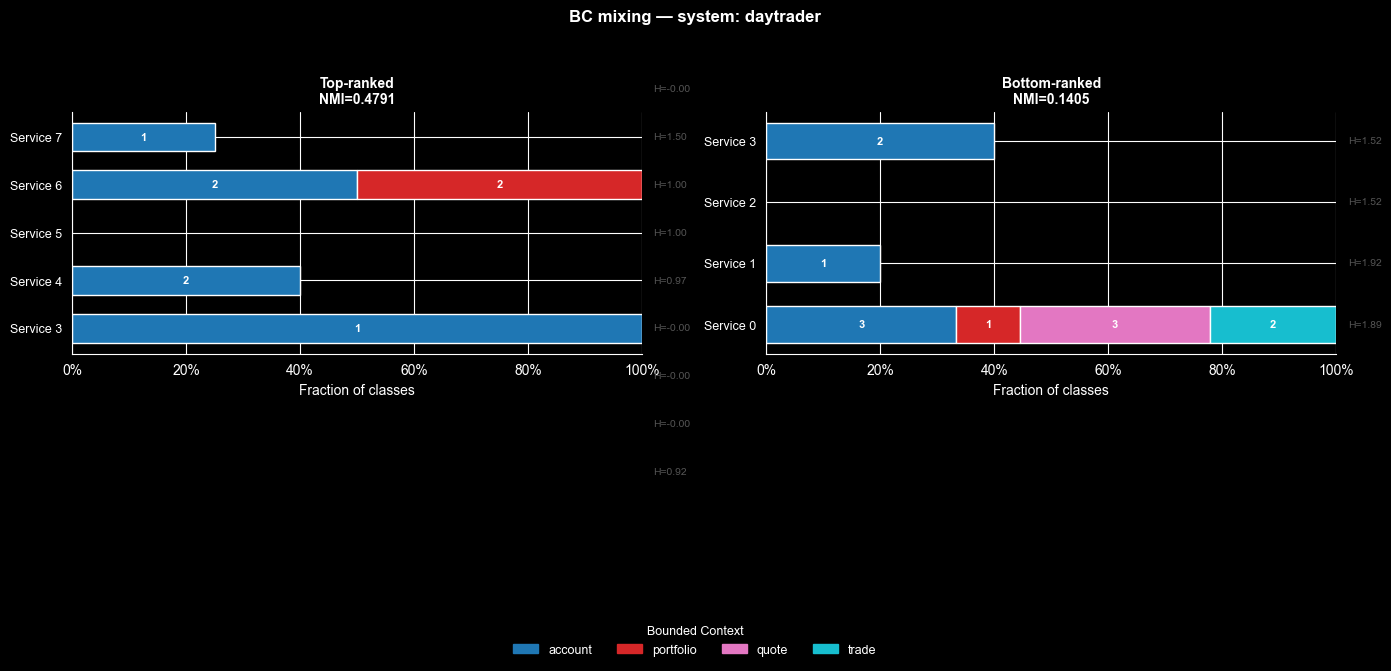

**BC mixing entropy — daytrader** (0 = pure single-BC, higher = more mixed)

rank,run_id,service,entropy,dominant_bc
top,_18_02_02_826045,0,0.918,trade
top,_18_02_02_826045,1,-0.000,quote
top,_18_02_02_826045,2,-0.000,portfolio
top,_18_02_02_826045,3,-0.000,account
top,_18_02_02_826045,4,0.971,trade
top,_18_02_02_826045,5,1.000,quote
top,_18_02_02_826045,6,1.000,portfolio
top,_18_02_02_826045,7,1.500,trade
top,_18_02_02_826045,8,-0.000,quote
bottom,_17_54_20_240991,0,1.891,account


In [7]:
for system in systems:
    df_sys = results[results[SYSTEM_COL] == system].sort_values('NMI', ascending=False)

    TOP_ID = df_sys.iloc[0]['ID']   # highest NMI
    BOT_ID = df_sys.iloc[-1]['ID']  # lowest NMI

    if not BC_MAPPING:
        print(f'[{system}] BC_MAPPING is empty — set it in the config cell before running this section.')
        continue

    plot_bc_mixing(system, TOP_ID, BOT_ID, BC_MAPPING)

    display(Markdown(f'**BC mixing entropy — {system}** (0 = pure single-BC, higher = more mixed)'))
    rows = []
    for run_id, label in [(TOP_ID, 'top'), (BOT_ID, 'bottom')]:
        mix = bc_mixing_df(run_id, BC_MAPPING)
        if mix.empty:
            continue
        ent = bc_mixing_entropy(mix).reset_index()
        ent.columns = ['service', 'entropy']
        ent.insert(0, 'rank', label)
        ent.insert(1, 'run_id', run_id[-16:])
        dominant = mix.sort_values('pct', ascending=False).groupby('service').first()['bc']
        ent['dominant_bc'] = ent['service'].map(dominant)
        rows.append(ent)
    if rows:
        tbl = pd.concat(rows, ignore_index=True)
        display(
            tbl.style
            .format({'entropy': '{:.3f}'})
            .background_gradient(subset=['entropy'], cmap='OrRd')
            .hide(axis='index')
        )

---
## 3  NMI Distribution
Distribution of NMI scores per system.

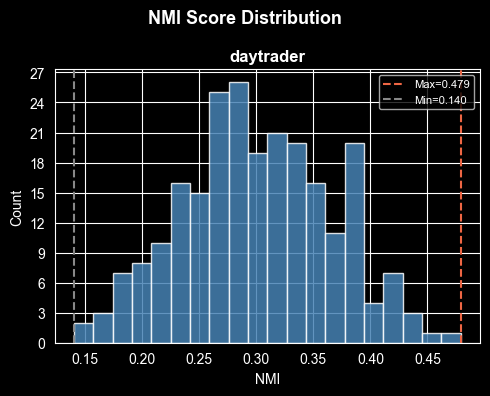

In [8]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, len(systems), figsize=(5 * len(systems), 4), squeeze=False)

for ax, system in zip(axes[0], systems):
    nmi_vals = results[results[SYSTEM_COL] == system]['NMI'].dropna()
    ax.hist(nmi_vals, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(nmi_vals.max(), color='#e64', linestyle='--', linewidth=1.5, label=f'Max={nmi_vals.max():.3f}')
    ax.axvline(nmi_vals.min(), color='#888', linestyle='--', linewidth=1.5, label=f'Min={nmi_vals.min():.3f}')
    ax.set_title(f'{system}', fontweight='bold')
    ax.set_xlabel('NMI')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

fig.suptitle('NMI Score Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4  Service Grouping Detail
Full class listing for any individual decomposition. Change `INSPECT_ID` to explore different runs.

In [9]:
# ── Set the run you want to inspect ──────────────────────────────────────────
INSPECT_ID = results.sort_values('NMI', ascending=False).iloc[0]['ID']
row = results[results['ID'] == INSPECT_ID]
nmi = row['NMI'].values[0] if not row.empty else '?'
display(Markdown(f"**Decomposition:** `{INSPECT_ID}`  |  **NMI:** {nmi:.4f}"))

df = membership_to_df(INSPECT_ID)

if df.empty:
    print("Run ID not found in pickle.")
else:
    for svc_id, group in df.groupby('service'):
        color = PALETTE[int(svc_id) % len(PALETTE)]
        patch = mpatches.Patch(color=color, label=f'Service {svc_id}')
        display(Markdown(f"#### 🔹 Service {svc_id}  ({len(group)} classes)"))
        tbl = group[['short_class', 'class']].rename(
            columns={'short_class': 'Class (short)', 'class': 'Fully-qualified name'}
        ).reset_index(drop=True)
        tbl.index += 1
        display(tbl.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

**Decomposition:** `04_03_18_02_02_826045`  |  **NMI:** 0.4791

#### 🔹 Service 0  (3 classes)

Class (short),Fully-qualified name
CompleteOrderThread,class:com.ibm.websphere.samples.daytrader.util.CompleteOrderThread
TradeSLSBLocal,class:com.ibm.websphere.samples.daytrader.ejb3.TradeSLSBLocal
TradeServices,class:com.ibm.websphere.samples.daytrader.TradeServices


#### 🔹 Service 1  (2 classes)

Class (short),Fully-qualified name
MarketSummaryDataBean,class:com.ibm.websphere.samples.daytrader.beans.MarketSummaryDataBean
MarketSummarySingleton,class:com.ibm.websphere.samples.daytrader.ejb3.MarketSummarySingleton


...

Class (short),Fully-qualified name
AccountDataBean,class:com.ibm.websphere.samples.daytrader.entities.AccountDataBean
AccountProfileDataBean,class:com.ibm.websphere.samples.daytrader.entities.AccountProfileDataBean
FinancialUtils,class:com.ibm.websphere.samples.daytrader.util.FinancialUtils
HoldingDataBean,class:com.ibm.websphere.samples.daytrader.entities.HoldingDataBean


#### 🔹 Service 7  (4 classes)

Class (short),Fully-qualified name
DTBroker3MDB,class:com.ibm.websphere.samples.daytrader.ejb3.DTBroker3MDB
DTStreamer3MDB,class:com.ibm.websphere.samples.daytrader.ejb3.DTStreamer3MDB
MDBStats,class:com.ibm.websphere.samples.daytrader.util.MDBStats
TimerStat,class:com.ibm.websphere.samples.daytrader.util.TimerStat


#### 🔹 Service 8  (2 classes)

Class (short),Fully-qualified name
KeySequenceDirect,class:com.ibm.websphere.samples.daytrader.direct.KeySequenceDirect
RunStatsDataBean,class:com.ibm.websphere.samples.daytrader.beans.RunStatsDataBean


---
## 5  Pen_data: Data-Access Penalty

Pen_data penalises decompositions where services share access to the same database tables,
surfacing violations that granularity-based metrics (e.g. service count) cannot detect.

This section requires the `mvaa` package in your environment and the following files per system:
- `monoliths/{system}/decompositions_{system}.pkl`
- `monoliths/{system}/mapper_to_tables.json`
- `monoliths/{system}/vista_implementacion_{system}.graphml`
- A pre-computed `pen_data_{system}.csv` (produced by `mvaa/tests/RQ1/data_penalty_analysis.py`,
  via `compute_do_metrics_for_many_decompositions`).

Set `PEN_DATA_CSV` below to the path of that CSV.

In [10]:
PEN_DATA_CONFIGS = {
    DEFAULT_SYSTEM_NAME: {
        'pen_data_csv': f'../results/RQ1/pen_data_{DEFAULT_SYSTEM_NAME}.csv',
        'project_path': f'../monoliths/{DEFAULT_SYSTEM_NAME}',
    },
}

In [ ]:
import json as _json
import pickle as _pickle
import matplotlib.ticker as ticker
from collections import defaultdict

from mvaa.metrics.data_restriction import (
    precompute_class_tx_bits,
    precompute_table_bits,
    compute_do_metrics_for_many_decompositions,
)


def load_pen_data(system: str) -> tuple:
    cfg = PEN_DATA_CONFIGS.get(system, {})
    csv_path = cfg.get('pen_data_csv', f'../results/RQ1/pen_data_{system}.csv')
    pen_df = pd.read_csv(csv_path)
    pen_df.columns = pen_df.columns.str.strip()
    pen_data_global = dict(zip(pen_df['ID'], pen_df['pen_data']))
    return pen_df, pen_data_global


def load_all_penalties(system: str) -> dict:
    cfg = PEN_DATA_CONFIGS.get(system, {})
    project_path = cfg.get('project_path', f'../monoliths/{system}')
    try:
        with open(f'{project_path}/decompositions_{system}.pkl', 'rb') as f:
            _decomps = _pickle.load(f)
        with open(f'{project_path}/mapper_to_tables.json', 'r') as f:
            _mapper = _json.load(f)
        _class_tx_bits, _ = precompute_class_tx_bits(
            f'{project_path}/vista_implementacion_{system}.graphml', tx_max_depth=2
        )
        _table_bit, _class_access_bits = precompute_table_bits(_mapper)
        all_penalties = compute_do_metrics_for_many_decompositions(
            decompositions=_decomps,
            class_access_bits=_class_access_bits,
            class_tx_bits=_class_tx_bits,
            only_pairs_with_overlap=True,
        )
        return all_penalties, _decomps, _mapper
    except FileNotFoundError as e:
        print(f'[{system}] Could not load penalty files: {e}')
        return {}, {}, {}


def cluster_summary(dec_id, _decompositions, _mapper_to_tables):
    mem = _decompositions[dec_id]['membership']
    clusters = defaultdict(list)
    for cls, cid in mem.items():
        simple = cls.replace('class:', '').split('.')[-1]
        clusters[cid].append(simple)
    cluster_tables = defaultdict(set)
    for cls, cid in mem.items():
        tables = _mapper_to_tables.get(cls, [])
        cluster_tables[cid].update(t.replace('table:', '') for t in tables)
    return dict(clusters), dict(cluster_tables)

### 5a  Pen_data ranking table

In [12]:
for system in systems:
    pen_df, pen_data_global = load_pen_data(system)

    ranked = pen_df.sort_values('pen_data').reset_index(drop=True)
    ranked.index += 1
    ranked.index.name = 'Rank'

    display(Markdown(f'### System: `{system}` — {len(ranked)} decompositions'))
    display(
        ranked.style
        .format({'pen_data': '{:.4f}'})
        .background_gradient(subset=['pen_data'], cmap='YlOrRd')
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
    )

### System: `daytrader` — 235 decompositions

,ID,pen_data
Rank,,
1,04_03_17_52_00_575877,0.0421
2,04_03_18_03_51_982413,0.0421
3,04_03_18_02_02_850690,0.0421
4,04_03_17_54_20_139418,0.0421
5,04_03_18_00_12_116297,0.0449
6,04_03_17_49_08_364749,0.0805
7,04_03_18_03_51_955242,0.0805
8,04_03_17_49_08_409032,0.0813
9,04_03_17_34_49_071033,0.0977


### 5b  Pen_data distribution

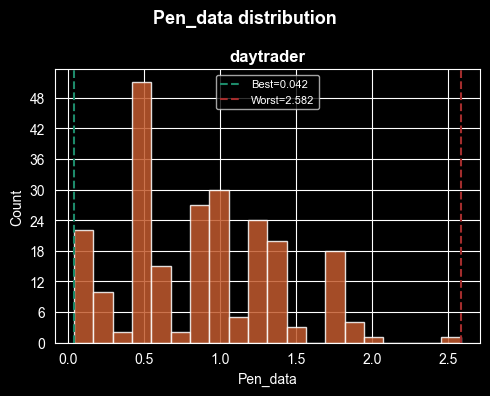

In [13]:
fig, axes = plt.subplots(1, len(systems), figsize=(5 * len(systems), 4), squeeze=False)

for ax, system in zip(axes[0], systems):
    _, pen_data_global = load_pen_data(system)
    vals = list(pen_data_global.values())

    ax.hist(vals, bins=20, color='#c25a2e', edgecolor='white', alpha=0.85)
    ax.axvline(min(vals), color='#1d8a6a', linestyle='--', linewidth=1.5,
               label=f'Best={min(vals):.3f}')
    ax.axvline(max(vals), color='#a32d2d', linestyle='--', linewidth=1.5,
               label=f'Worst={max(vals):.3f}')
    ax.set_title(system, fontweight='bold')
    ax.set_xlabel('Pen_data')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

fig.suptitle('Pen_data distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5c  Top vs bottom: penalized pairs detail

For the best- and worst-ranked decompositions, shows which service pairs share tables
and how much each pair contributes to the total Pen_data score.

Best Pen_data: 04_03_17_52_00_575877 = 0.0421


## System: `daytrader`

**Best (lowest Pen_data)** (`04_03_17_52_00_575877`)  |  Pen_data = 0.0421  |  2 penalized pairs

pair,penalty,shared tables,n_shared
S1 ↔ S7,0.0357,"ACCOUNTEJB, ACCOUNTPROFILEEJB, HOLDINGEJB, KEYGENEJB, ORDEREJB, QUOTEEJB",6
S1 ↔ S3,0.0064,QUOTEEJB,1


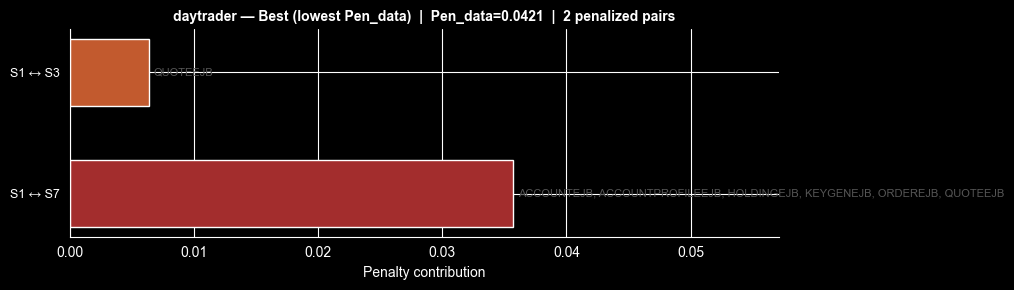

**Worst (highest Pen_data)** (`04_03_17_40_47_398189`)  |  Pen_data = 2.5820  |  12 penalized pairs

pair,penalty,shared tables,n_shared
S4 ↔ S6,0.7931,"ACCOUNTEJB, ACCOUNTPROFILEEJB, HOLDINGEJB, KEYGENEJB, ORDEREJB, QUOTEEJB",6
S3 ↔ S6,0.4000,"ACCOUNTEJB, ACCOUNTPROFILEEJB, HOLDINGEJB, KEYGENEJB, ORDEREJB, QUOTEEJB",6
S3 ↔ S4,0.3929,"ACCOUNTEJB, ACCOUNTPROFILEEJB, HOLDINGEJB, KEYGENEJB, ORDEREJB, QUOTEEJB",6
S1 ↔ S4,0.2500,"ACCOUNTEJB, ACCOUNTPROFILEEJB, HOLDINGEJB, KEYGENEJB, ORDEREJB, QUOTEEJB",6
S1 ↔ S3,0.2000,"ACCOUNTEJB, ACCOUNTPROFILEEJB, HOLDINGEJB, KEYGENEJB, ORDEREJB, QUOTEEJB",6
S1 ↔ S6,0.1923,"ACCOUNTEJB, ACCOUNTPROFILEEJB, HOLDINGEJB, KEYGENEJB, ORDEREJB, QUOTEEJB",6
S4 ↔ S7,0.1429,"ACCOUNTEJB, ACCOUNTPROFILEEJB, HOLDINGEJB, KEYGENEJB, ORDEREJB, QUOTEEJB",6
S1 ↔ S7,0.1000,"ACCOUNTEJB, ACCOUNTPROFILEEJB, HOLDINGEJB, KEYGENEJB, ORDEREJB, QUOTEEJB",6
S3 ↔ S7,0.0714,"ACCOUNTEJB, ACCOUNTPROFILEEJB, HOLDINGEJB, KEYGENEJB, ORDEREJB, QUOTEEJB",6
S0 ↔ S1,0.0208,QUOTEEJB,1


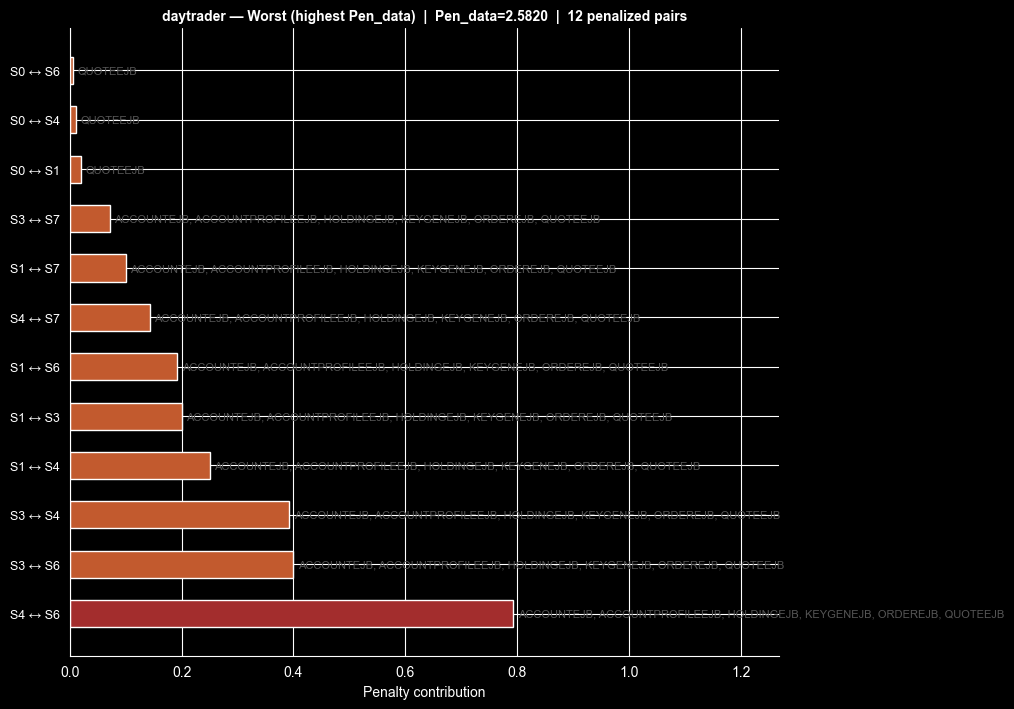

In [14]:
def plot_penalized_pairs(system, dec_id, label, pairs, _decompositions, _mapper_to_tables, pen_score):
    if not pairs:
        print(f'  [{label}] No penalized pairs.')
        return

    _, cluster_tables = cluster_summary(dec_id, _decompositions, _mapper_to_tables)
    sorted_pairs = sorted(pairs.items(), key=lambda x: x[1], reverse=True)

    pair_labels = [f'S{si} ↔ S{sj}' for (si, sj), _ in sorted_pairs]
    pair_vals   = [v for _, v in sorted_pairs]
    shared_tables = [
        cluster_tables.get(si, set()) & cluster_tables.get(sj, set())
        for (si, sj), _ in sorted_pairs
    ]

    fig_h = max(3, len(pair_labels) * 0.5 + 1.2)
    fig, ax = plt.subplots(figsize=(10, fig_h))

    colors = ['#a32d2d' if v == max(pair_vals) else '#c25a2e' for v in pair_vals]
    bars = ax.barh(pair_labels, pair_vals, color=colors, height=0.55)

    for bar, tables in zip(bars, shared_tables):
        table_str = ', '.join(sorted(tables)) if tables else ''
        ax.text(
            bar.get_width() + max(pair_vals) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            table_str, va='center', ha='left', fontsize=8,
            color='#555'
        )

    ax.set_xlabel('Penalty contribution')
    ax.set_title(
        f'{system} — {label}  |  Pen_data={pen_score:.4f}  |  {len(pairs)} penalized pairs',
        fontsize=10, fontweight='bold'
    )
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=9)
    # extra right margin for table annotations
    ax.set_xlim(0, max(pair_vals) * 1.6)
    plt.tight_layout()
    plt.show()


def pen_data_detail_table(dec_id, label, pairs, _decompositions, _mapper_to_tables, pen_score):

    _, cluster_tables = cluster_summary(dec_id, _decompositions, _mapper_to_tables)
    rows = []
    for (si, sj), pen in sorted(pairs.items(), key=lambda x: x[1], reverse=True):
        shared = cluster_tables.get(si, set()) & cluster_tables.get(sj, set())
        rows.append({
            'pair': f'S{si} ↔ S{sj}',
            'penalty': pen,
            'shared tables': ', '.join(sorted(shared)),
            'n_shared': len(shared),
        })
    df_pairs = pd.DataFrame(rows)
    display(Markdown(
        f'**{label}** (`{dec_id}`)  |  '
        f'Pen_data = {pen_score:.4f}  |  '
        f'{len(pairs)} penalized pairs'
    ))
    display(
        df_pairs.style
        .format({'penalty': '{:.4f}'})
        .background_gradient(subset=['penalty'], cmap='YlOrRd')
        .hide(axis='index')
    )


for system in systems:
    pen_df, pen_data_global = load_pen_data(system)
    best_id  = min(pen_data_global, key=pen_data_global.get)
    worst_id = max(pen_data_global, key=pen_data_global.get)
    print(f'Best Pen_data: {best_id} = {pen_data_global[best_id]:.4f}')

    all_penalties, _decomps, _mapper = load_all_penalties(system)

    display(Markdown(f'## System: `{system}`'))

    for dec_id, label in [(best_id, 'Best (lowest Pen_data)'), (worst_id, 'Worst (highest Pen_data)')]:
        pen_score = pen_data_global[dec_id]
        pairs = all_penalties.get(dec_id, {})

        if _decomps and _mapper:
            pen_data_detail_table(dec_id, label, pairs, _decomps, _mapper, pen_score)
            plot_penalized_pairs(system, dec_id, label, pairs, _decomps, _mapper, pen_score)
        else:
            display(Markdown(
                f'**{label}** (`{dec_id}`)  |  '
                f'Pen_data = {pen_score:.4f}  |  '
                f'*(pair detail unavailable — source files not found)*'
            ))

---
## 6  All Systems — NMI Summary Table
Compact cross-system comparison of top, median, and bottom NMI, plus number of decompositions.

In [15]:
rows = []
for system in systems:
    vals = results[results[SYSTEM_COL] == system]['NMI'].dropna()
    rows.append({
        'System': system,
        'N': len(vals),
        'NMI max': vals.max(),
        'NMI median': vals.median(),
        'NMI min': vals.min(),
        'NMI std': vals.std(),
    })

summary = pd.DataFrame(rows).set_index('System')
display(
    summary.style
    .format({'NMI max': '{:.4f}', 'NMI median': '{:.4f}', 'NMI min': '{:.4f}', 'NMI std': '{:.4f}'})
    .background_gradient(subset=['NMI max', 'NMI median'], cmap='YlGn')
)

,N,NMI max,NMI median,NMI min,NMI std
System,,,,,
daytrader,235,0.4791,0.2982,0.1405,0.0655


## 7  NMI_filtered: rank-delta analysis

`NMI_filtered` re-ranks decompositions after removing infrastructural or singleton classes
whose isolation artificially lowers per-service entropy (e.g. `AbstractActionBean` in JPetStore).

This section shows, per system:
- **Rank delta table** — raw NMI rank vs filtered NMI rank, sorted by |Δ| descending.
- **Scatter plot** — raw rank vs filtered rank; points off the diagonal lost or gained positions.
  Colour encodes the signed delta (red = dropped, blue = rose).
- **Spearman ρ** between the two rankings, printed per system.

### System: `daytrader`  |  Spearman ρ = 0.920  (p = 5.890e-97)  |  13 / 235 decompositions unchanged

ID,rank_raw,rank_filtered,delta,NMI,NMI_filtered,SERVICES
04_03_18_03_51_982413,91,187,+96,0.3236,0.2646,8
04_03_18_03_51_969715,65,152,+87,0.3412,0.3009,8
04_03_18_03_51_997303,58,145,+87,0.3526,0.3113,7
04_03_18_02_02_850690,38,118,+80,0.3753,0.3282,8
04_03_18_03_51_964981,30,109,+79,0.3824,0.3389,8
04_03_17_40_47_333181,201,141,-60,0.2330,0.3145,5
04_03_18_00_12_116297,8,68,+60,0.4199,0.3800,9
04_03_17_40_47_305106,207,150,-57,0.2245,0.3048,5
04_03_17_40_47_338157,121,70,-51,0.2947,0.3749,6
04_03_17_46_33_078741,146,95,-51,0.2780,0.3502,5


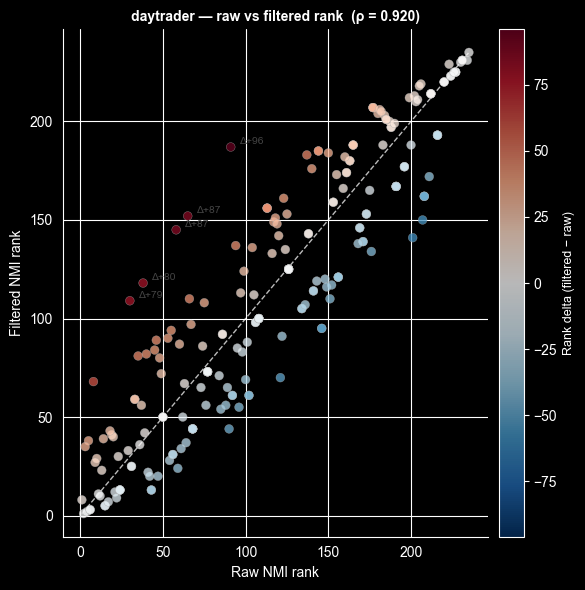

In [16]:
from scipy.stats import spearmanr

def rank_delta_analysis(system: str):
    df = results[results[SYSTEM_COL] == system].copy()

    df['rank_raw']      = df['NMI'].rank(ascending=False, method='min').astype(int)
    df['rank_filtered'] = df['NMI_filtered'].rank(ascending=False, method='min').astype(int)
    df['delta']         = df['rank_filtered'] - df['rank_raw']

    rho, p = spearmanr(df['rank_raw'], df['rank_filtered'])

    display(Markdown(
        f"### System: `{system}`  |  "
        f"Spearman ρ = {rho:.3f}  (p = {p:.3e})  |  "
        f"{(df['delta'] == 0).sum()} / {len(df)} decompositions unchanged"
    ))

    tbl = (
        df[['ID', 'rank_raw', 'rank_filtered', 'delta', 'NMI', 'NMI_filtered', 'SERVICES']]
        .sort_values('delta', key=abs, ascending=False)
        .reset_index(drop=True)
    )
    tbl.index += 1

    def _color_delta(val):
        if val > 0:
            intensity = min(val / df['delta'].abs().max(), 1.0)
            r = int(255 * intensity)
            return f'color: rgb({r}, 50, 50); font-weight: 500'
        elif val < 0:
            intensity = min(abs(val) / df['delta'].abs().max(), 1.0)
            b = int(200 * intensity)
            return f'color: rgb(30, 80, {b + 55}); font-weight: 500'
        return 'color: #888'

    display(
        tbl.style
        .format({
            'NMI': '{:.4f}', 'NMI_filtered': '{:.4f}',
            'delta': '{:+d}',
        })
        .applymap(_color_delta, subset=['delta'])
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
        .hide(axis='index')
    )

    n = len(df)
    max_delta = df['delta'].abs().max()

    fig, ax = plt.subplots(figsize=(6, 6))

    sc = ax.scatter(
        df['rank_raw'], df['rank_filtered'],
        c=df['delta'], cmap='RdBu_r', vmin=-max_delta, vmax=max_delta,
        s=40, alpha=0.75, linewidths=0.3, edgecolors='#aaa'
    )

    ax.plot([1, n], [1, n], color='#bbb', linewidth=1, linestyle='--', zorder=0)

    top_movers = df.reindex(df['delta'].abs().nlargest(5).index)
    for _, row in top_movers.iterrows():
        ax.annotate(
            f"Δ{row['delta']:+d}",
            xy=(row['rank_raw'], row['rank_filtered']),
            xytext=(6, 2), textcoords='offset points',
            fontsize=7.5, color='#444'
        )

    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label('Rank delta (filtered − raw)', fontsize=9)

    ax.set_xlabel('Raw NMI rank')
    ax.set_ylabel('Filtered NMI rank')
    ax.set_title(
        f'{system} — raw vs filtered rank  (ρ = {rho:.3f})',
        fontsize=10, fontweight='bold'
    )
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


for system in systems:
    rank_delta_analysis(system)